In [40]:
import torch
import torch.distributions as td
import numpy as np
import matplotlib.pyplot as plt

import copy
import matplotlib.gridspec as gridspec
import time
from torch.nn.utils import clip_grad_norm_

In [41]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)
    
    def U(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return - torch.logsumexp(args, 1)

    def grad_U(self, x_init):
        x = x_init.detach()
        x = x.requires_grad_()
        optimizer = torch.optim.SGD([x], lr=0)
        optimizer.zero_grad()
        loss = self.U(x).sum()
        loss.backward()
        return x.grad.data

sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]
#shift_means = [torch.tensor([-sep*0.8, 0]), torch.tensor([sep, 0])]

target = MoG(means, covars, weights=[0.2, 0.8])
#prop = MoG(shift_means, covars)

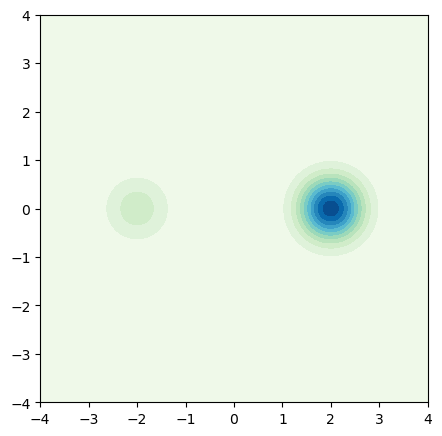

In [42]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

In [43]:
from flonacomldft.models.real_nvp import RealNVP_MLP

In [44]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

In [45]:
from flonacomldft.train_flow_from_data import train_flow

In [46]:
n_samples = 10000

target_samples = target.sample(n_samples)
target_us = target.U(target_samples)
id_mode = torch.zeros(n_samples)

dataset = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T
dataset

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


tensor([[ 1.4366,  0.0148,  1.2455,  0.0000],
        [ 2.0491, -0.8266,  2.1657,  0.0000],
        [-2.9318,  0.1124,  4.0403,  0.0000],
        ...,
        [ 1.8208,  0.7576,  1.9669,  0.0000],
        [ 2.1041, -0.3339,  0.7574,  0.0000],
        [ 1.7454, -1.0162,  3.1950,  0.0000]])

In [47]:
train = dataset[:int(n_samples*0.8)]
test = dataset[int(n_samples*0.8):]

train.shape, test.shape

(torch.Size([8000, 4]), torch.Size([2000, 4]))

In [48]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=1000,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(100000/10),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
)

t=0.0e+00 	 loss: 4.03	Gd: 2e+00	lr: 1.00e-03
t=1.0e+02 	 loss: 2.53	Gd: 4e-02	lr: 1.00e-03
t=2.0e+02 	 loss: 2.33	Gd: 2e-01	lr: 1.00e-03
t=3.0e+02 	 loss: 1.99	Gd: 1e-01	lr: 1.00e-03
t=4.0e+02 	 loss: 1.79	Gd: 4e-02	lr: 1.00e-03
t=5.0e+02 	 loss: 1.76	Gd: 2e-02	lr: 1.00e-03
t=6.0e+02 	 loss: 1.75	Gd: 9e-02	lr: 1.00e-03
t=7.0e+02 	 loss: 1.75	Gd: 1e-01	lr: 1.00e-03
t=8.0e+02 	 loss: 1.74	Gd: 7e-02	lr: 1.00e-03
t=9.0e+02 	 loss: 1.74	Gd: 9e-02	lr: 1.00e-03


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


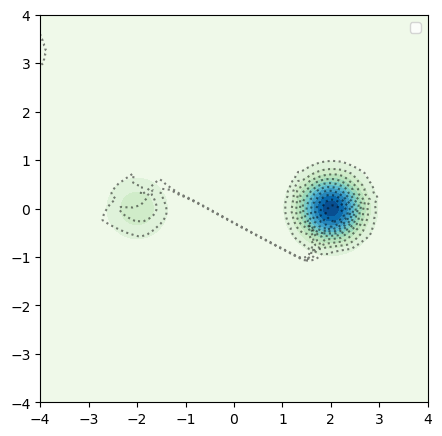

In [49]:
fig, ax = plt.subplots(1,1, figsize=(5,7))
flowlogprob = lambda x: -flow_dic['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
#plt.scatter(train[:,0].detach().numpy(), train[:,1].detach().numpy(), label='train')
#plt.scatter(test[:,0], test[:,1], label='test')
#plt.scatter(flow_samples[:,0].detach().numpy(), flow_samples[:,1].detach().numpy(), label='flow')
plt.legend()

In [50]:
n_samples = 100
target_samples = target.sample(n_samples)
target_samples
target_us = target.U(target_samples)
target_us
id_mode = torch.zeros(n_samples)
id_mode
init = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T
n_chains = init.shape[0]
n_steps = 100


In [51]:
from flonacomldft.sampling import run_metropolis

In [52]:

kb = 8.617333262e-5
T = 300
beta = 1 / (kb * T)
target_energy = lambda x: target.U(x) / beta

_ = run_metropolis(flow_dic['model'], init, n_chains, n_steps, dim=2,
                   energy_type='mlp', mlp_models=target_energy)


step: 0 	 acc: 1.00
step: 10 	 acc: 0.87
step: 20 	 acc: 0.92
step: 30 	 acc: 0.89
step: 40 	 acc: 0.86
step: 50 	 acc: 0.92
step: 60 	 acc: 0.86
step: 70 	 acc: 0.88
step: 80 	 acc: 0.89
step: 90 	 acc: 0.93


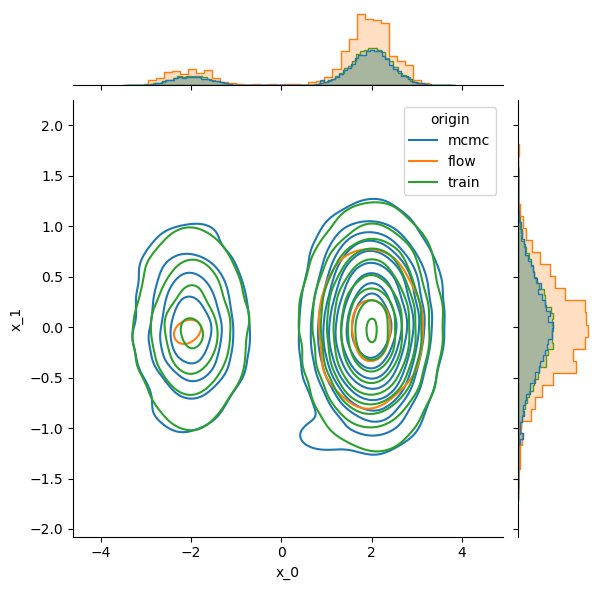

In [53]:
xs = _['xs']
flow_samples = flow_dic['model'].sample(1000) 

import seaborn as sns
import pandas as pd

datas = [
            xs.view(-1,2).detach().numpy(), 
            flow_samples.detach().numpy(),
            train.detach().numpy()
]
labels = ['mcmc', 'flow', 'train']

frames = []
for d, l in zip(datas, labels):
    df = pd.DataFrame(
        {"x_{:d}".format(0): d[:,0], "x_{:d}".format(1): d[:, 1]}
    )
    df["origin"] = l
    frames.append(df)

dfs = pd.concat(frames, ignore_index=True)
g = sns.JointGrid(
    data=dfs, x="x_{:d}".format(0), y="x_{:d}".format(1), hue="origin"
)
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot, element="step", fill=True, stat='probability', common_bins=False, common_norm=False)


